In [ ]:
!pip install seaborn

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
# The previous attempt to scrape data from quotes.ino.com resulted in an HTTP 403 Forbidden error.
# This means the website denied access to the request, likely to prevent automated scraping.
# Data is being loaded successfully from yfinance and a local CSV in subsequent cells.

In [18]:
import yfinance as yf

tickers = ['MMM', "AXP", 'AAPL', "BA", "CVX", 	"CSCO", 	"KO", 	"DIS"]

df = pd.DataFrame(columns=tickers)
for ticker in tickers:
  data = yf.download(ticker)
  df[ticker]=data.Close

/tmp/ipython-input-4117695246.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4117695246.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4117695246.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4117695246.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-4117695246.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker)
[********

In [21]:
df['DJI'] = yf.download('^DJI').Close

/tmp/ipython-input-914382538.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df['DJI'] = yf.download('^DJI').Close
[*********************100%***********************]  1 of 1 completed


In [22]:
df.head()

,MMM,AXP,AAPL,BA,CVX,CSCO,KO,DIS,DJI
Date,,,,,,,,,
2025-10-07,155.330002,327.141083,256.480011,221.820007,154.910004,68.989998,66.790001,112.529999,46602.980469
2025-10-08,156.000000,323.001587,258.059998,225.320007,153.740005,70.330002,66.120003,111.889999,46601.781250
2025-10-09,152.880005,323.619995,254.039993,216.000000,151.639999,69.959999,66.370003,110.989998,46358.421875
2025-10-10,148.750000,316.260010,245.270004,210.729996,148.899994,67.940002,67.040001,109.190002,45479.601562
2025-10-13,151.100006,323.119995,247.660004,215.559998,151.940002,67.459999,66.800003,110.269997,46067.578125


In [27]:
data = df.copy()
dow = data[['DJI']]
data = data.drop(['DJI'], axis = 1)

In [30]:
ret = data.pct_change().dropna().mean() * 250   # annualize
std = data.pct_change().dropna().std() * np.sqrt(250)   # annualized
mkrs = ret.index.tolist()

/tmp/ipython-input-2557255754.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(std[i], ret[i])
/tmp/ipython-input-2557255754.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(mkrs[i], (std[i], ret[i]))


Text(0.5, 1.0, 'Return vs. Std in Dow')

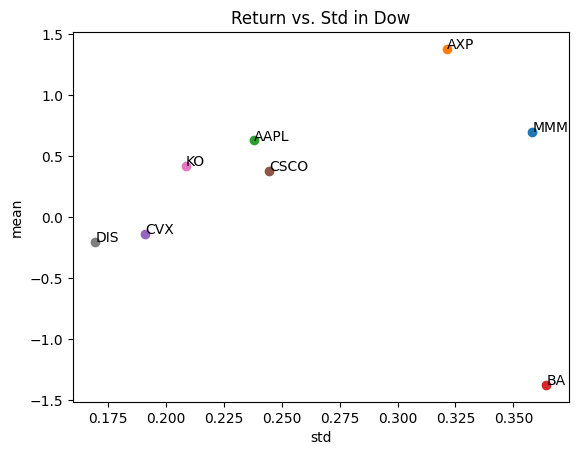

In [31]:
for i in range(len(ret)):
    plt.scatter(std[i], ret[i])
    plt.annotate(mkrs[i], (std[i], ret[i]))
plt.xlabel('std')
plt.ylabel('mean')
plt.title("Return vs. Std in Dow")

### KMeans clustering

In [32]:
### oops in python

class Test:
    def __init__(self, n):
        pass

    def build(self, input_shape):
        pass
    def call(self, x):
        return x **2

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans()   # instantiation

In [34]:
df= pd.DataFrame().assign(ret=ret, std=std)

In [36]:
elbow_score = []
for k in range(5, len(df) + 1):  # Maximum number of clusters should not exceed the number of samples
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    elbow_score.append(kmeans.inertia_)   # cluster's coherence

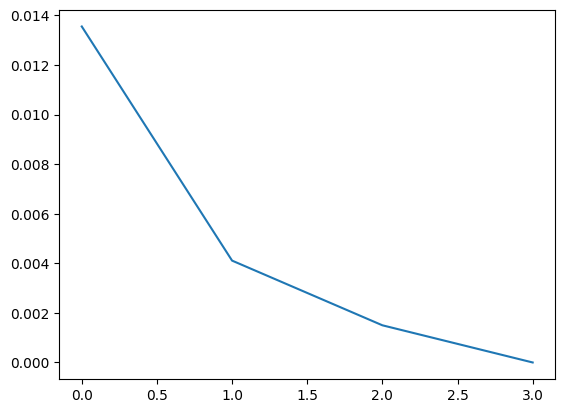

In [37]:
plt.plot(elbow_score)

In [38]:
# based on elbow score

#k = 10
k = 3
kmeans = KMeans(n_clusters=k)
kmeans.fit(df)
centeroid = kmeans.cluster_centers_



/tmp/ipython-input-2803361140.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(mkrs[i], (std[i], ret[i]))


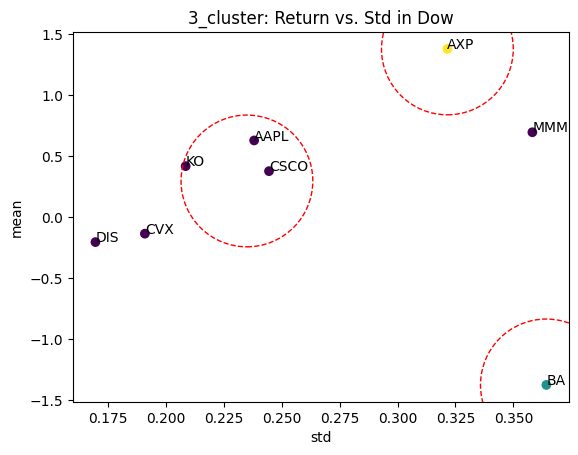

In [39]:
plt.scatter(df['std'], df['ret'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('std')
plt.ylabel('mean')
plt.title(f"{k}_cluster: Return vs. Std in Dow")

mkrs = ret.index.tolist()
for i in range(len(df)):
    plt.annotate(mkrs[i], (std[i], ret[i]))

for i in range(len(centeroid)):
    plt.scatter(centeroid[i, 1], centeroid[i, 0], s=9000, marker='o', linestyle="--", edgecolor='r', facecolors="none")


### Cluster with eigenvalue

In [ ]:
df_2 = data.pct_change().dropna()

In [ ]:
df_2.describe()

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,MSFT,NKE,PFE,PG,TRV,UNH,VZ,V,WMT,WBA
count,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,...,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000,2813.000000
mean,0.000360,0.000611,0.001148,0.000751,0.000631,0.000257,0.000364,0.000257,0.000750,0.000060,...,0.000831,0.000870,0.000320,0.000303,0.000491,0.000982,0.000262,0.000936,0.000377,0.000240
std,0.013698,0.018317,0.017891,0.022448,0.018428,0.017218,0.017003,0.011119,0.015787,0.015274,...,0.016009,0.016267,0.012971,0.010883,0.014131,0.016422,0.011251,0.016240,0.012039,0.017769
min,-0.129450,-0.148187,-0.128647,-0.238484,-0.142822,-0.221248,-0.162107,-0.096725,-0.129846,-0.122248,...,-0.147390,-0.116667,-0.077346,-0.087373,-0.208004,-0.172769,-0.066205,-0.135472,-0.101832,-0.143374
25%,-0.005324,-0.006519,-0.007188,-0.008570,-0.008287,-0.007314,-0.006649,-0.004720,-0.006298,-0.006813,...,-0.006951,-0.006987,-0.006033,-0.004696,-0.005618,-0.007006,-0.006025,-0.006906,-0.005182,-0.008029
50%,0.000706,0.000699,0.000893,0.000764,0.000392,0.000400,0.000455,0.000433,0.000600,-0.000122,...,0.000673,0.000688,0.000000,0.000327,0.000848,0.000866,0.000496,0.001313,0.000437,0.000263
75%,0.007019,0.008625,0.010384,0.009830,0.010023,0.007722,0.008058,0.005711,0.007874,0.007085,...,0.008636,0.008830,0.006672,0.005482,0.007056,0.008706,0.006388,0.008848,0.006005,0.009161
max,0.125986,0.218823,0.119808,0.243186,0.103321,0.227407,0.159505,0.064796,0.144123,0.126868,...,0.142169,0.151752,0.089607,0.120090,0.132903,0.127989,0.076802,0.149973,0.117085,0.126036


In [ ]:
eVal0, eVec0 = np.linalg.eigh(df_2.cov())

In [ ]:
weights = eVec0[:, -1] / np.sum(eVec0[:, -1])

In [ ]:
np.dot(df_2, weights.T)

array([ 0.00076818, -0.00848404,  0.01554493, ..., -0.00522018,
        0.00063723, -0.00934749])

In [ ]:
ret2 = (df_2 * weights).mean()  * 250
std2 = (df_2 * weights).std() * np.sqrt(250)

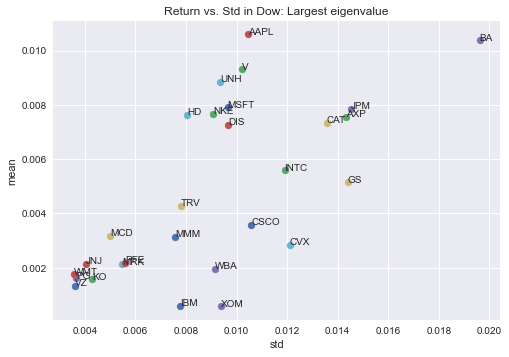

In [ ]:
for i in range(len(ret2)):
    plt.scatter(std2[i], ret2[i])
    plt.annotate(mkrs[i], (std2[i], ret2[i]))
plt.xlabel('std')
plt.ylabel('mean')
plt.title("Return vs. Std in Dow: Largest eigenvalue");

In [ ]:
df2= pd.DataFrame().assign(ret=ret2, std=std2)

In [ ]:
k = 3
kmeans2 = KMeans(n_clusters=k)
kmeans2.fit(df2)
centeroid2 = kmeans2.cluster_centers_



/tmp/ipython-input-808715980.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(mkrs[i], (std2[i], ret2[i]))


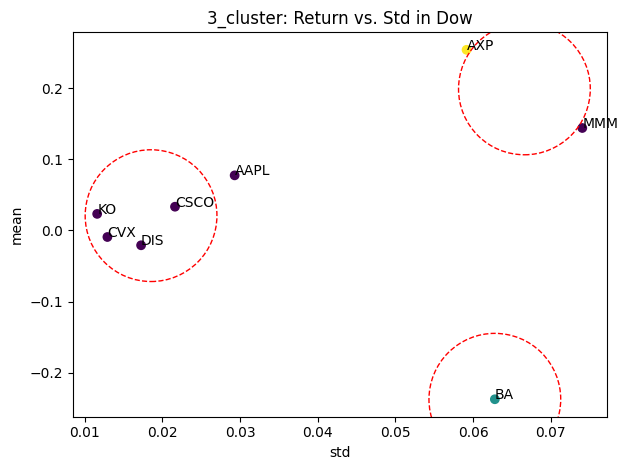

In [45]:
df_2 = data.pct_change().dropna()
eVal0, eVec0 = np.linalg.eigh(df_2.cov())
weights = eVec0[:, -1] / np.sum(eVec0[:, -1])
ret2 = (df_2 * weights).mean() * 250
std2 = (df_2 * weights).std() * np.sqrt(250)
df2= pd.DataFrame().assign(ret=ret2, std=std2)

k = 3
kmeans2 = KMeans(n_clusters=k)
kmeans2.fit(df2)
centeroid2 = kmeans2.cluster_centers_

plt.scatter(df2['std'], df2['ret'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('std')
plt.ylabel('mean')
plt.title(f"{k}_cluster: Return vs. Std in Dow")

mkrs = ret.index.tolist()
for i in range(len(df2)):
    plt.annotate(mkrs[i], (std2[i], ret2[i]))

for i in range(len(centeroid2)):
    plt.scatter(centeroid2[i, 1], centeroid2[i, 0], s=9000, marker='o', linestyle="--", edgecolor='r', facecolors="none")

plt.tight_layout()

In [46]:
print(ret2.mean()/std2.mean())

0.9173749517128901


In [47]:
print(ret.mean()/std.mean())

0.8526278440224287
